<a href="https://colab.research.google.com/github/SrinathEindhoven/tensorflow/blob/master/GradientDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

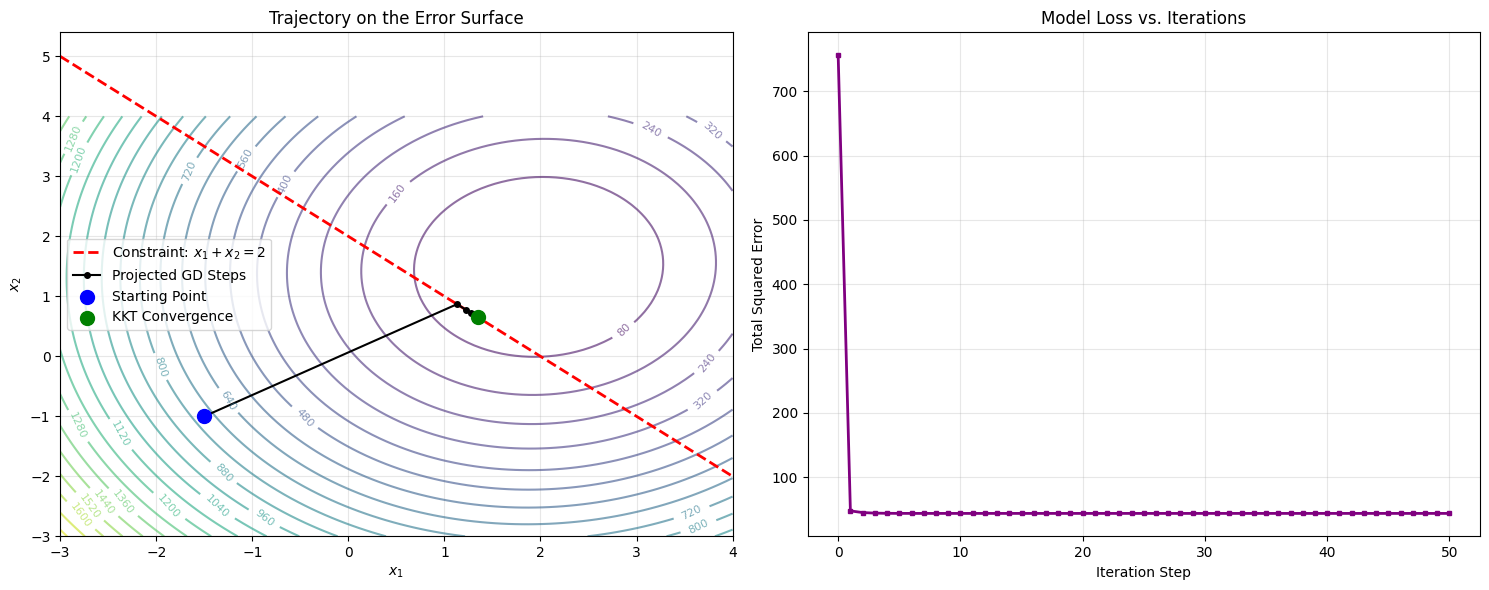

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate a small, clean 2D dataset to easily visualize in a 2D plot
np.random.seed(0)
n_samples = 40
n_features = 2  # Two parameters to fit: x1 and x2

A = np.random.randn(n_samples, n_features)
true_param = np.array([[2.0], [1.5]])
b = A @ true_param + np.random.randn(n_samples, 1) * 0.2

# 2. Define our linear equality constraint: x1 + x2 = 2
# Written as C*x = d -> [1, 1]*[x1, x2]' = 2
C = np.array([[1.0, 1.0]])
d = np.array([[2.0]])

# 3. Precompute Objective Function matrices
H = 2.0 * (A.T @ A)
g = 2.0 * (A.T @ b)

def compute_loss(x):
    # Loss = ||Ax - b||^2
    residuals = A @ x - b
    return np.sum(residuals**2)

# 4. Iterative Projected Gradient Descent Algorithm
learning_rate = 0.005
iterations = 50

# Start at an arbitrary initial guess far away from the constraint line
x_current = np.array([[-1.5], [-1.0]])

# Lists to log history for visualization
history_x = [x_current.copy()]
history_loss = [compute_loss(x_current)]

for step in range(iterations):
    # Step A: Compute the raw gradient of the objective function
    grad = (H @ x_current) - g

    # Step B: Take a standard gradient descent step (unconstrained)
    x_unconstrained = x_current - learning_rate * grad

    # Step C: Project the point back onto the constraint line (C*x = d)
    # This formula mathematically snaps the point to the closest valid coordinate
    projection_adjustment = C.T @ np.linalg.solve(C @ C.T, C @ x_unconstrained - d)
    x_current = x_unconstrained - projection_adjustment

    # Log progress
    history_x.append(x_current.copy())
    history_loss.append(compute_loss(x_current))

# Convert history lists to numpy arrays for plotting
history_x = np.array(history_x).squeeze()

# 5. Create Grid Data to Plot the Error Contour Bowl
x1_vals = np.linspace(-3, 4, 100)
x2_vals = np.linspace(-3, 4, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)
Z_loss = np.zeros(X1.shape)

for i in range(100):
    for j in range(100):
        grid_point = np.array([[X1[i, j]], [X2[i, j]]])
        Z_loss[i, j] = compute_loss(grid_point)

# 6. Plotting the Convergence
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: The Loss Landscape and Trajectory
contour = ax1.contour(X1, X2, Z_loss, levels=25, cmap='viridis', alpha=0.6)
ax1.clabel(contour, inline=True, fontsize=8)

# Draw the constraint line: x1 + x2 = 2  ->  x2 = 2 - x1
ax1.plot(x1_vals, 2.0 - x1_vals, color='red', linestyle='--', linewidth=2, label='Constraint: $x_1 + x_2 = 2$')

# Plot the path taken by the algorithm
ax1.plot(history_x[:, 0], history_x[:, 1], color='black', marker='o', markersize=4, linewidth=1.5, label='Projected GD Steps')
ax1.scatter(history_x[0, 0], history_x[0, 1], color='blue', s=100, zorder=5, label='Starting Point')
ax1.scatter(history_x[-1, 0], history_x[-1, 1], color='green', s=100, zorder=5, label='KKT Convergence')

ax1.set_title('Trajectory on the Error Surface')
ax1.set_xlabel('$x_1$')
ax1.set_ylabel('$x_2$')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Loss reduction over time
ax2.plot(range(len(history_loss)), history_loss, color='purple', linewidth=2, marker='s', markersize=3)
ax2.set_title('Model Loss vs. Iterations')
ax2.set_xlabel('Iteration Step')
ax2.set_ylabel('Total Squared Error')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()